#### Features in Chatbot:
<ol>
<li> Chatting </li>
<li> RAG </li>
<li> Tools </li>
<li> UI </li>
<li> LangSmith </li>
<li> Advance LangGraph </li>
    <ol type="a">
    <li> Memory </li>
    <li> Persistence </li>
    <li> HITL </li>
    <li> Retry/Fault Tolerance </li>
    </ol>
</ol>

### PART 1 - Simple ChatBot

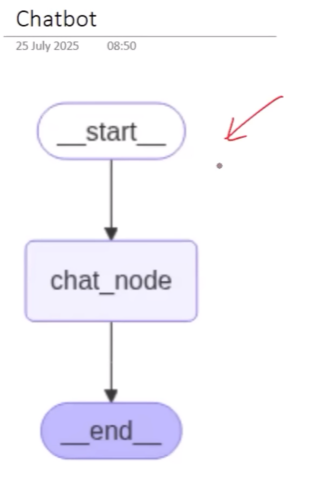

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI


In [3]:
from langgraph.graph.message import add_messages

In [ ]:
class ChatState(TypedDict):
    # You can also use list[str] but using BaseMessage is better
    # So there are different message types like :
    # HumanMessage, AIMessage, SystemMessage..these are inherited from BaseMessage
    # So we use BaseMessage to show that we can have human message or ai message or system message
    # add_messages is a reducer function as it is more optimized when working with messages.
    messages: Annotated[list[BaseMessage], add_messages]

In [13]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [14]:
def chat_node(state: ChatState):
    message = state["messages"]

    response = llm.invoke(message)

    return {'messages': response}



In [16]:
graph = StateGraph(ChatState)

#nodes
graph.add_node('chat_node',chat_node)

#edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

In [18]:
chatbot = graph.compile()

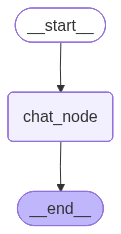

In [19]:
chatbot

In [20]:
initial_state = {
    'messages': [HumanMessage(content="What is the capital of India in year 1400")]
}

result = chatbot.invoke(initial_state)

In [21]:
result['messages'][-1].content

'In the year 1400, the capital of India was not a singular entity as India was not a unified nation at that time. Instead, it was a region characterized by various kingdoms and principalities. Some prominent capitals during that time included:\n\n- **Delhi**, which was a significant political center and had numerous rulers over the centuries.\n- **Vijayanagara**, which was the capital of the Vijayanagara Empire in southern India that flourished in the 14th century.\n- **Jaipur**, as part of the Kachwaha Rajputs, though it became prominent later on.\n\nThe political landscape was diverse, with different dynasties such as the Delhi Sultanate wielding power in different parts of the subcontinent. Therefore, the concept of a "capital of India" did not exist in the modern sense during that era.'

In [24]:
result

{'messages': [HumanMessage(content='What is the capital of India in year 1400', additional_kwargs={}, response_metadata={}, id='00571567-63a5-485b-ad68-e901e9815301'),
  AIMessage(content='In the year 1400, the capital of India was not a singular entity as India was not a unified nation at that time. Instead, it was a region characterized by various kingdoms and principalities. Some prominent capitals during that time included:\n\n- **Delhi**, which was a significant political center and had numerous rulers over the centuries.\n- **Vijayanagara**, which was the capital of the Vijayanagara Empire in southern India that flourished in the 14th century.\n- **Jaipur**, as part of the Kachwaha Rajputs, though it became prominent later on.\n\nThe political landscape was diverse, with different dynasties such as the Delhi Sultanate wielding power in different parts of the subcontinent. Therefore, the concept of a "capital of India" did not exist in the modern sense during that era.', additiona

In [27]:
# Infinite chatting until user quits
while True:
    
    user_message = input("User Message: ")

    print('User:', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    result = chatbot.invoke({
        'messages': [HumanMessage(content=user_message)]
    })

    print(result['messages'][-1].content)
    print("==================================")


User: What was the capital of France in 1780?
The capital of France in 1780 was Paris. Paris has been the capital of France for much of its history, including during the late 18th century.
User: What is football made of?
A football, also known as a soccer ball in some countries, is typically made of several materials. The outer cover is usually made from synthetic materials, such as polyurethane or PVC, which provide durability and water resistance. The bladder inside the ball is often made from latex or butyl rubber, which helps maintain air pressure and shape. 

The construction and materials can vary depending on the level of play and the quality of the ball. Higher-end footballs may have a more complex construction with additional layers for better performance, while lower-end balls may use simpler materials. Additionally, many modern footballs have a machine-stitched or thermally bonded design for improved consistency and performance.
User: When will winter olympic take place afte

In [30]:
# This code got no memory because in each loop, the workflow keeps ending
# so it fails to remember your name or store any info.
while True:
    
    user_message = input("User Message: ")

    print('User:', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    result = chatbot.invoke({
        'messages': [HumanMessage(content=user_message)]
    })

    print("AI: ",result['messages'][-1].content)
    print("==================================")

User: My name is ankit
AI:  Nice to meet you, Ankit! How can I assist you today?
User: What is my name?
AI:  I don't have access to personal information, so I'm unable to know your name. However, you can tell me what you'd like to be called!
User: quit


When the workflow reaches to __end__, the state gets erased. So we can use persistence to store the state after the workflow reaches __end__ node instead of erasing. So either store the state in DB or RAM.

In [31]:
from langgraph.checkpoint.memory import MemorySaver

In [32]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

#nodes
graph.add_node('chat_node',chat_node)

#edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

In [33]:
chatbot = graph.compile(checkpointer=checkpointer)

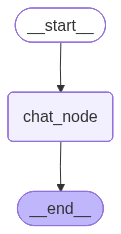

In [34]:
chatbot

In [36]:
thread_id = '1' #Thread is basically one interaction with chatbot

while True:
    
    user_message = input("User Message: ")

    print('User:', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    config = {'configurable': {'thread_id': thread_id}}

    result = chatbot.invoke({
        'messages': [HumanMessage(content=user_message)]
    }, config=config)

    print("AI: ",result['messages'][-1].content)
    print("==================================")

User: Hi, My name is Ankit
AI:  Hi Ankit! How can I assist you today?
User: I like ice-cream
AI:  Ice cream is a delicious treat! Do you have a favorite flavor?
User: I work as a senior data scientist
AI:  That's great! As a senior data scientist, you must be working on some interesting projects. What kind of data science work do you specialize in?
User: What do you know about me
AI:  I know that your name is Ankit, you like ice cream, and you work as a senior data scientist. If you'd like to share more about yourself or your interests, feel free to do so!
User: quit


In [ ]:
# This shows you the whole conversation history
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi, My name is Ankit', additional_kwargs={}, response_metadata={}, id='6b6dde42-0446-4dc1-a1d4-2c9213b86780'), AIMessage(content='Hi Ankit! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 14, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_373a14eb6f', 'id': 'chatcmpl-DBbpUt7VWIV4Fz0wo8mKcjVSnSgFG', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--df29f46e-0cf3-4af2-b242-500c961737e8-0', usage_metadata={'input_tokens': 14, 'output_tokens': 11, 'total_tokens': 25, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning

: 